In [310]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/tenerife-camp-contest-titanic/sample_submission.csv
/kaggle/input/competitions/tenerife-camp-contest-titanic/train.csv
/kaggle/input/competitions/tenerife-camp-contest-titanic/test.csv


In [311]:
train_ds= pd.read_csv("/kaggle/input/competitions/tenerife-camp-contest-titanic/train.csv")
test_ds =pd.read_csv("/kaggle/input/competitions/tenerife-camp-contest-titanic/test.csv")
sample_sub =pd.read_csv("/kaggle/input/competitions/tenerife-camp-contest-titanic/sample_submission.csv")

In [312]:
train_ds.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [314]:
train_ds.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize',
       'IsAlone', 'FamilyGroup', 'Deck', 'HasCabin', 'TicketGroupSize',
       'FarePerPerson', 'AgeGroup', 'TicketPrefix', 'FareGroup', 'Sex_Pclass',
       'Age_Pclass', 'FarePerPerson_Pclass', 'Child', 'Mother'],
      dtype='object')

In [315]:
train_ds = train_ds.drop("Ticket",axis = 1)
test_ds = test_ds.drop("Ticket",axis = 1)
train_ds = train_ds.drop("PassengerId",axis =1) 
test_ds = test_ds.drop("PassengerId",axis =1) 
train_ds["Cabin"] = train_ds["Cabin"].fillna("Unkown")
test_ds["Cabin"]= test_ds["Cabin"].fillna("Unkown")

In [316]:
train_ds["HasCabin"]= train_ds["Cabin"].apply(lambda x: x!= "Unkown")
test_ds["HasCabin"]= test_ds["Cabin"].apply(lambda x: x!= "Unkown")

In [317]:
train_ds["HasCabin"]

0      False
1       True
2      False
3       True
4      False
       ...  
886    False
887     True
888    False
889     True
890    False
Name: HasCabin, Length: 891, dtype: bool

In [318]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer().fit(train_ds[["Age"]])
test_ds["Age"]= imputer.transform(test_ds[["Age"]])
train_ds["Age"]= imputer.transform(train_ds[["Age"]])

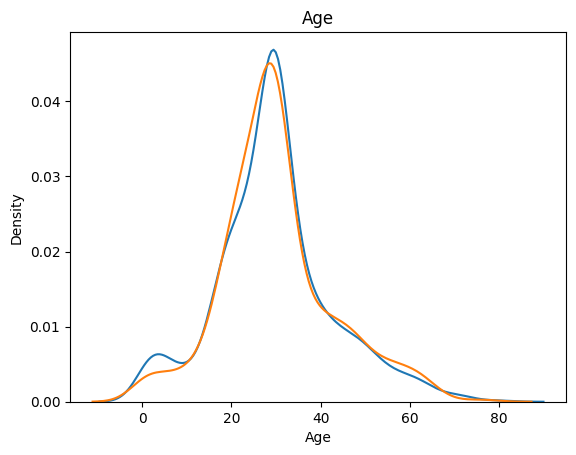

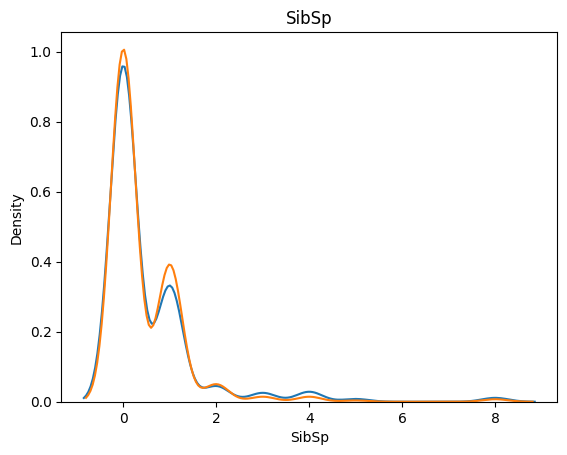

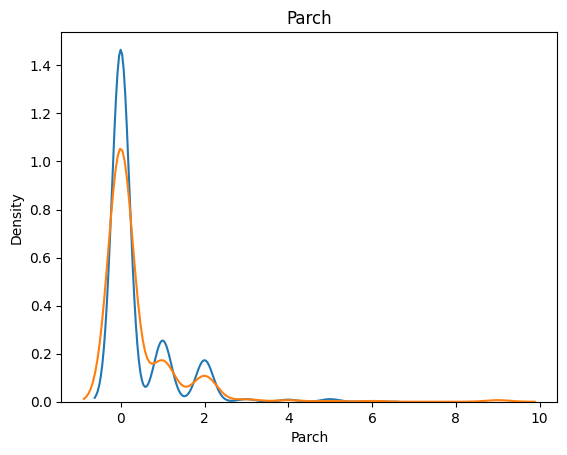

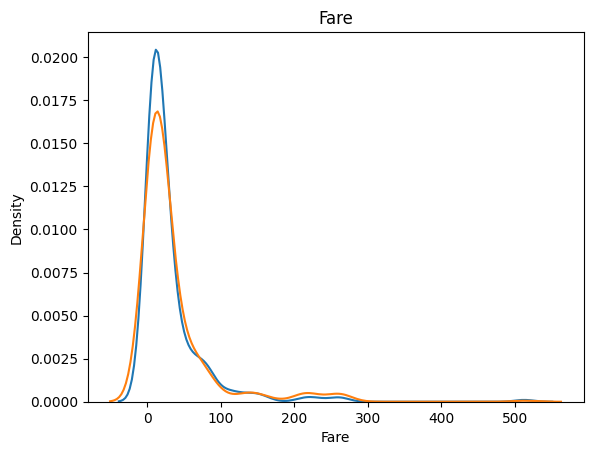

In [319]:
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
for col in num_cols:
    sns.kdeplot(train_ds[col])
    sns.kdeplot(test_ds[col])
    plt.title(col)
    plt.show()

In [322]:
cat_cols= ["Sex", "HasCabin"]
num_cols =["Age", "SibSp","Parch","Fare"]

In [323]:
train_ds[cat_cols]

,Sex,Embarked,Title,FamilyGroup,Deck,TicketPrefix,AgeGroup,Sex_Pclass
0,male,S,Mr,Small,Unknown,A,YoungAdult,male_3
1,female,C,Mrs,Small,C,PC,Adult,female_1
2,female,S,Miss,Alone,Unknown,STONO,YoungAdult,female_3
3,female,S,Mrs,Small,C,NUMERIC,YoungAdult,female_1
4,male,S,Mr,Alone,Unknown,NUMERIC,YoungAdult,male_3
...,...,...,...,...,...,...,...,...
886,male,S,Other,Alone,Unknown,NUMERIC,YoungAdult,male_2
887,female,S,Miss,Alone,B,NUMERIC,YoungAdult,female_1
888,female,S,Miss,Small,Unknown,WC,Unknown,female_3
889,male,C,Mr,Alone,C,NUMERIC,YoungAdult,male_1


In [325]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value =-1).fit(train_ds[cat_cols])
train_ds[cat_cols] =encoder.transform(train_ds[cat_cols])
test_ds[cat_cols] =encoder.transform(test_ds[cat_cols])
scaler=StandardScaler().fit(train_ds[num_cols])
train_ds[num_cols]=scaler.transform(train_ds[num_cols])
test_ds[num_cols]=scaler.transform(test_ds[num_cols])

In [326]:
train_ds.isnull().sum()

Survived                0
Pclass                  0
Name                    0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Cabin                   0
Embarked                2
Title                   0
FamilySize              0
IsAlone                 0
FamilyGroup             0
Deck                    0
HasCabin                0
TicketGroupSize         0
FarePerPerson           0
AgeGroup                0
TicketPrefix            0
FareGroup               0
Sex_Pclass              0
Age_Pclass              0
FarePerPerson_Pclass    0
Child                   0
Mother                  0
dtype: int64

In [252]:
!pip install lazypredict

In [327]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train_ds[X_cols], train_ds["Survived"], test_size = 0.2, random_state= 67)
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_val, y_train, y_val)

print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
SVC                            0.843575           0.834760  0.842361   
NuSVC                          0.843575           0.833035  0.834951   
NearestCentroid                0.826816           0.820197  0.836995   
CalibratedClassifierCV         0.826816           0.818472  0.846960   
LinearSVC                      0.826816           0.818472  0.846576   
LinearDiscriminantAnalysis     0.826816           0.818472  0.849387   
RidgeClassifierCV              0.826816           0.818472  0.849387   
RidgeClassifier                0.826816           0.818472  0.849387   
GaussianNB                     0.821229           0.815342  0.838784   
LogisticRegression             0.821229           0.811893  0.844660   
PassiveAggressiveClassifier    0.815642           0.810488  0.831886   
CatBoostClassifier             0.810056           0.803909  0.84

In [ ]:
test_ds['Fare'] = test_ds['Fare'].fillna(test_ds['Fare'].median())

In [330]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier().fit(train_ds[X_cols], train_ds["Survived"])
sample_sub["Survived"] =cat.predict(test_ds[X_cols])

Learning rate set to 0.009807
0:	learn: 0.6893981	total: 2.33ms	remaining: 2.33s
1:	learn: 0.6842764	total: 3.76ms	remaining: 1.88s
2:	learn: 0.6779651	total: 5.09ms	remaining: 1.69s
3:	learn: 0.6722602	total: 6.37ms	remaining: 1.59s
4:	learn: 0.6687417	total: 7.29ms	remaining: 1.45s
5:	learn: 0.6652517	total: 8.17ms	remaining: 1.35s
6:	learn: 0.6603325	total: 9.65ms	remaining: 1.37s
7:	learn: 0.6555167	total: 10.9ms	remaining: 1.34s
8:	learn: 0.6506515	total: 12ms	remaining: 1.32s
9:	learn: 0.6457398	total: 13.6ms	remaining: 1.34s
10:	learn: 0.6408545	total: 14.8ms	remaining: 1.33s
11:	learn: 0.6364562	total: 15.8ms	remaining: 1.3s
12:	learn: 0.6336327	total: 16.4ms	remaining: 1.25s
13:	learn: 0.6308696	total: 17ms	remaining: 1.2s
14:	learn: 0.6261299	total: 18.2ms	remaining: 1.19s
15:	learn: 0.6226334	total: 19ms	remaining: 1.17s
16:	learn: 0.6185570	total: 20.1ms	remaining: 1.16s
17:	learn: 0.6147054	total: 21.3ms	remaining: 1.16s
18:	learn: 0.6114631	total: 22.2ms	remaining: 1.14s


In [331]:
sample_sub.to_csv("tit11.csv",index= False)

In [ ]:
sample_sub["Survived"].value_counts()